## Executive Function, Stress, and Impulsive Decision-Making: A Moderation and Predictive Modeling Analysis
#### Author: Kevin Olvera  

---

### Project Motivation

Stress can influence how people make decisions. One common idea in behavioral science is that under greater stress, people may become more likely to favor smaller immediate rewards over larger delayed rewards, a pattern often interpreted as more impulsive decision-making.

A possible protective factor is **executive function (EF)**: a broad set of cognitive control processes involved in attention regulation, working memory, and flexible goal-directed behavior. If executive function helps people stay regulated under pressure, then stronger EF may weaken the relationship between stress and impulsive choice.

This project tests that idea using behavioral data from the **Human Connectome Project – Young Adult (HCP-YA 2025 release)**.

---

### Scientific Question

**Does executive function buffer the relationship between stress and being impulsive?**

In statistical terms, this is a **moderation question**:

- Does the association between perceived stress and impulsive decision-making change depending on someone's executive function score?

---

### Why This Question Matters

This question matters for both theory and application.

- If stress is linked to more impulsive decision-making, that helps explain why self-regulation varies across people.
- If executive function acts as a buffer, it may point to a cognitive mechanism that protects against stress-related decision vulnerability.
- Testing both **inferential models** and **predictive models** helps distinguish between:
  - relationships that are statistically detectable in-sample
  - relationships that are useful for predicting unseen individuals

---

### Outcome: Delay Discounting

For the sake of this project, impulsive decision-making is operationalized using **Delay Discounting Area Under the Curve (AUC)**:

- **Higher AUC** = less impulsive decision-making
- **Lower AUC** = steeper discounting / greater impulsivity

---

### Project Roadmap

This notebook proceeds in five stages:

1. Load and validate the HCP behavioral data  
2. Construct an executive function composite  
3. Test linear and nonlinear moderation models with robust OLS  
4. Evaluate out-of-sample predictive performance using OLS, Ridge, and Elastic Net  
5. Summarize what the analyses do and do not support  

### 0. Environment & Reproducibility

This section imports the required libraries and sets a random seed.

The random seed makes results that involve randomness, such as the train/test split, reproducible.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.linear_model import LinearRegression, RidgeCV, ElasticNetCV
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from IPython.display import display

# Reproducibility
RANDOM_STATE = 72
np.random.seed(RANDOM_STATE)

# Display settings for readability
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

### 1. Data Acquisition & Preparation

Data were downloaded in two parts and merged on participant ID.

This project uses data from the **Human Connectome Project – Young Adult 2025 release (HCP-YA)**, a large behavioral and cognitive dataset of adults ages 22–35.

Because the data were stored across two files, a careful merge step is important to ensure that each row still corresponds to the correct participant.

In [2]:
behavior_part1 = pd.read_csv("../data/hcp_subjectdata_part1.csv")
behavior_part2 = pd.read_csv("../data/hcp_subjectdata_part2.csv")

print(f"Part 1 shape: {behavior_part1.shape}")
print(f"Part 2 shape: {behavior_part2.shape}")

Part 1 shape: (1206, 14)
Part 2 shape: (1206, 6)


### 1.1 Merge & Integrity Checks

The files are merged using `Subject` as the participant ID.

I use:

- `how="inner"` to keep only participants present in both files
- `validate="one_to_one"` to ensure that each participant appears only once in each file

If the merge were not truly one-to-one, pandas would raise an error here.

In [3]:
subject_id_col = "Subject"

merged_df = behavior_part1.merge(
    behavior_part2,
    on=subject_id_col,
    how="inner",
    validate="one_to_one"
)

print(f"Merged shape: {merged_df.shape}")
print(f"Unique subject IDs: {merged_df[subject_id_col].nunique()}")
print(f"Duplicate subject IDs after merge: {merged_df[subject_id_col].duplicated().sum()}")

Merged shape: (1206, 19)
Unique subject IDs: 1206
Duplicate subject IDs after merge: 0


### 1.2 Variable Validation

Before running the models, I check that all required variables are present in the dataset.

In [4]:
required_variables = [
    "DDisc_AUC_200",
    "Flanker_AgeAdj", "CardSort_AgeAdj", "ListSort_AgeAdj",
    "PercStress_Unadj",
    "PMAT24_A_CR", "ProcSpeed_AgeAdj",
    "NEOFAC_C", "NEOFAC_N", "NEOFAC_E",
    "FearAffect_Unadj", "AngHostil_Unadj", "Sadness_Unadj", "PosAffect_Unadj",
]

missing_variables = [col for col in required_variables if col not in merged_df.columns]

if missing_variables:
    raise ValueError(f"Missing required variables: {missing_variables}")
else:
    print("All required variables are present.")

All required variables are present.


### 1.3 Missingness Summary

Analyses were conducted using **complete-case observations (listwise deletion)**, excluding participants with missing values on any modeling variable.

This approach is straightforward and ensures all models are fit on complete data, though it may reduce sample size and introduce bias if missingness is systematic.

Given the modest level of missingness, this approach is reasonable for the present analysis.

In [5]:
missingness_summary = (
    merged_df[required_variables]
    .isna()
    .sum()
    .sort_values(ascending=False)
    .rename("n_missing")
    .to_frame()
)

missingness_summary["pct_missing"] = 100 * missingness_summary["n_missing"] / len(merged_df)
missingness_summary

,n_missing,pct_missing
PMAT24_A_CR,9,0.7463
DDisc_AUC_200,8,0.6633
NEOFAC_N,7,0.5804
NEOFAC_E,7,0.5804
NEOFAC_C,7,0.5804
CardSort_AgeAdj,3,0.2488
Sadness_Unadj,1,0.0829
AngHostil_Unadj,1,0.0829
PercStress_Unadj,1,0.0829
FearAffect_Unadj,1,0.0829


In [6]:
analytic_df = merged_df.dropna(subset=required_variables).copy()

n_original = len(merged_df)
n_complete = len(analytic_df)
n_removed = n_original - n_complete
pct_retained = 100 * n_complete / n_original

print(f"Original sample size: {n_original}")
print(f"Complete-case sample size: {n_complete}")
print(f"Rows removed by listwise deletion: {n_removed}")
print(f"Percent retained: {pct_retained:.1f}%")

Original sample size: 1206
Complete-case sample size: 1193
Rows removed by listwise deletion: 13
Percent retained: 98.9%


### 2. Measures & Feature Engineering

This section prepares the variables used in the analysis.

The primary inferential variables are:

- **Delay Discounting (`DDisc_AUC_200`)**: measured using Area Under the Curve (AUC) from choices between smaller immediate rewards and larger delayed rewards; lower values indicate greater impulsive decision-making  
- **Perceived Stress (`PercStress_Unadj`)**: self-reported stress  
- **Executive Function Composite**: based on Flanker, Card Sort, and List Sort task performance  

Additional cognitive, personality, and affective variables are included later in the predictive modeling section.

Continuous variables are standardized using z-scores so they are on a common scale and easier to compare across predictors.

### Executive Function Task Components

The executive function composite is constructed from three cognitive tasks capturing complementary components of cognitive control:

- **Flanker Task (`Flanker_AgeAdj`)**: measures inhibitory control and selective attention by requiring participants to respond to a target stimulus while ignoring surrounding distractors  
- **Card Sort Task (`CardSort_AgeAdj`)**: measures cognitive flexibility by requiring participants to shift between changing sorting rules  
- **List Sort Task (`ListSort_AgeAdj`)**: measures working memory by requiring participants to recall and reorder items  

Together, these tasks represent core components of executive function. Because each task captures only part of the broader construct and includes task-specific variance, standardized scores are averaged to form a more stable composite measure.

In [7]:
def zscore(series: pd.Series) -> pd.Series:
    """Standardize a pandas Series using the sample mean and sample SD."""
    return (series - series.mean()) / series.std(ddof=1)


# Core variable names
outcome_var = "DDisc_AUC_200"
stress_var = "PercStress_Unadj"
ef_task_vars = ["Flanker_AgeAdj", "CardSort_AgeAdj", "ListSort_AgeAdj"]

# Standardize focal outcome and predictor
analytic_df["delay_discounting_z"] = zscore(analytic_df[outcome_var])
analytic_df["perceived_stress_z"] = zscore(analytic_df[stress_var])

# Standardize EF task indicators individually
for task_var in ef_task_vars:
    analytic_df[f"{task_var}_z"] = zscore(analytic_df[task_var])

# Average standardized EF tasks row-wise for each participant
ef_standardized_cols = [f"{task_var}_z" for task_var in ef_task_vars]
analytic_df["ef_composite_raw"] = analytic_df[ef_standardized_cols].mean(axis=1)

# Re-standardize the composite for cleaner interpretation
analytic_df["ef_composite_z"] = zscore(analytic_df["ef_composite_raw"])

# Quadratic stress term for the nonlinear model
analytic_df["perceived_stress_z_sq"] = analytic_df["perceived_stress_z"] ** 2

analytic_df[
    ["delay_discounting_z", "perceived_stress_z", "ef_composite_z", "perceived_stress_z_sq"]
].describe()

,delay_discounting_z,perceived_stress_z,ef_composite_z,perceived_stress_z_sq
count,1193.0000,1193.0000,1193.0000,1193.0000
mean,0.0000,-0.0000,-0.0000,0.9992
std,1.0000,1.0000,1.0000,1.5178
min,-1.1791,-2.8479,-3.2835,0.0000
25%,-0.7439,-0.6419,-0.6897,0.0950
50%,-0.2909,-0.0413,0.0463,0.4042
75%,0.4314,0.6249,0.7354,1.2598
max,3.5476,3.4969,2.5739,12.2286


### 2.1 Executive Function Composite Reliability

Executive function is treated here as a broader construct rather than a single task score, so the three standardized task measures are combined into a composite to reduce task-specific noise and better capture shared cognitive control processes.

Cronbach's alpha is used as a basic internal consistency check to assess whether the task scores show enough shared variance to justify combining them.

Alpha provides a simple reliability check but does not fully capture the latent structure of executive function; more advanced approaches (e.g., factor analysis) could be used but are not necessary for the present analysis.

In [8]:
def cronbach_alpha(items_df: pd.DataFrame) -> float:
    """Compute Cronbach's alpha for a set of task/item columns."""
    complete_items = items_df.dropna().copy()
    n_items = complete_items.shape[1]

    item_variances = complete_items.var(axis=0, ddof=1)

    # Variance of the participant-level total score across items
    total_score_variance = complete_items.sum(axis=1).var(ddof=1)

    alpha_value = (n_items / (n_items - 1)) * (1 - item_variances.sum() / total_score_variance)
    return alpha_value


ef_alpha = cronbach_alpha(analytic_df[ef_standardized_cols])

print(f"Cronbach's alpha for EF task composite: {ef_alpha:.3f}")

Cronbach's alpha for EF task composite: 0.549


### 2.2 Checking the Core Variables

Before modeling, I look at basic summaries of the key variables to make sure the values are reasonable and that standardization worked as expected.

The standardized variables have means near zero and standard deviations near one, indicating that the transformation was applied correctly. No obvious anomalies are observed in the variable ranges.

In [9]:
data_check = analytic_df[
    [outcome_var, stress_var, *ef_task_vars, "delay_discounting_z", "perceived_stress_z", "ef_composite_z"]
].describe()

data_check

,DDisc_AUC_200,PercStress_Unadj,Flanker_AgeAdj,CardSort_AgeAdj,ListSort_AgeAdj,delay_discounting_z,perceived_stress_z,ef_composite_z
count,1193.0000,1193.0000,1193.0000,1193.0000,1193.0000,1193.0000,1193.0000,1193.0000
mean,0.2574,48.4781,101.4123,101.9012,103.0446,0.0000,-0.0000,-0.0000
std,0.2050,9.1571,10.1462,10.0654,13.3328,1.0000,1.0000,1.0000
min,0.0157,22.4000,69.3100,55.3900,60.0900,-1.1791,-2.8479,-3.2835
25%,0.1049,42.6000,94.7800,95.2400,94.3300,-0.7439,-0.6419,-0.6897
50%,0.1977,48.1000,101.7000,101.9100,102.6300,-0.2909,-0.0413,0.0463
75%,0.3458,54.2000,108.9200,109.5600,112.6600,0.4314,0.6249,0.7354
max,0.9844,80.5000,123.5600,122.6500,140.8600,3.5476,3.4969,2.5739


### 2.3 Relationships Among Core Variables  

Before fitting regression models, it is useful to examine how the primary variables are related.

This provides context for the moderation analysis by describing relationships among perceived stress, delay discounting, and executive function.

Correlation values range from **-1 to 1**, where values closer to **±1** indicate stronger relationships and values near **0** indicate weak linear associations.

This step does not test the moderation hypothesis directly, but it helps describe the overall relationships in the data before moving to regression.

In [10]:
core_corr = analytic_df[
    ["delay_discounting_z", "perceived_stress_z", "ef_composite_z"]
].corr()

core_corr

,delay_discounting_z,perceived_stress_z,ef_composite_z
delay_discounting_z,1.0000,-0.0663,0.0645
perceived_stress_z,-0.0663,1.0000,-0.1294
ef_composite_z,0.0645,-0.1294,1.0000


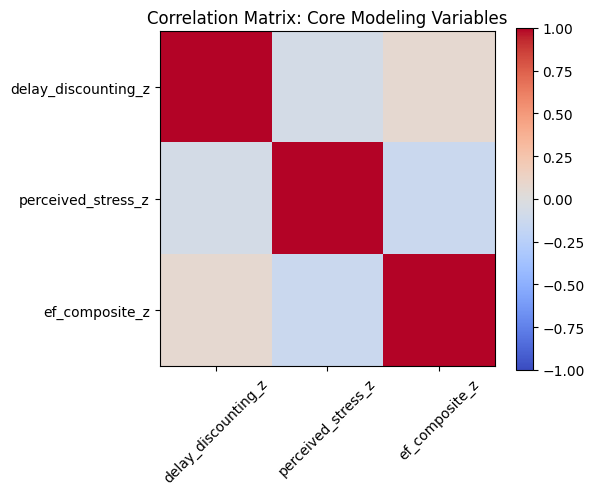

In [11]:
plt.figure(figsize=(6, 5))

plt.imshow(core_corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()

plt.xticks(range(len(core_corr)), core_corr.columns, rotation=45)
plt.yticks(range(len(core_corr)), core_corr.columns)

plt.title("Correlation Matrix: Core Modeling Variables")
plt.tight_layout()
plt.show()

The correlations among the core variables were small in magnitude. Perceived stress was only weakly related to delay discounting (r = -0.07), and executive function was also only weakly related to delay discounting (r = 0.06).

A somewhat stronger, though still modest, negative association appeared between executive function and perceived stress (r = -0.13), suggesting that higher executive function was associated with slightly lower reported stress.

Overall, the pairwise relationships were weak, indicating limited simple linear association among the core variables before regression.

### 3. Inferential Models: Does EF Buffer Stress-Related Impulsivity?

We now test the research question using a moderation model.

A **moderation model** tests whether the relationship between two variables changes depending on a third variable.

In this project:

- predictor = perceived stress  
- outcome = delay discounting  
- moderator = executive function  

The key test is the interaction term:

- `perceived_stress_z * ef_composite_z`

### What does the interaction mean?

It asks whether the relationship between stress and delay discounting differs depending on executive function level.

If executive function buffers the relationship, then the association between stress and delay discounting should vary at lower versus higher levels of EF.

### Model specification

The analysis uses a linear moderation model:

delay_discounting_z ~ perceived_stress_z * ef_composite_z

### 3.1 Comparing Models

Before interpreting the full moderation model, it is helpful to compare simpler models first.

This shows whether adding executive function and the interaction term improves model fit.

The models compared are:

- **Model 1:** perceived stress only  
- **Model 2:** perceived stress + executive function  
- **Model 3:** perceived stress + executive function + stress × executive function  

In [12]:
model_1 = smf.ols(
    "delay_discounting_z ~ perceived_stress_z",
    data=analytic_df
).fit(cov_type="HC3")

model_2 = smf.ols(
    "delay_discounting_z ~ perceived_stress_z + ef_composite_z",
    data=analytic_df
).fit(cov_type="HC3")

model_3 = smf.ols(
    "delay_discounting_z ~ perceived_stress_z * ef_composite_z",
    data=analytic_df
).fit(cov_type="HC3")

model_comparison = pd.DataFrame({
    "model": ["Stress only", "Stress + EF", "Stress × EF"],
    "r_squared": [model_1.rsquared, model_2.rsquared, model_3.rsquared],
    "adj_r_squared": [model_1.rsquared_adj, model_2.rsquared_adj, model_3.rsquared_adj]
})

model_comparison

,model,r_squared,adj_r_squared
0,Stress only,0.0044,0.0036
1,Stress + EF,0.0076,0.0059
2,Stress × EF,0.0102,0.0077


The models explain only a small amount of variance in delay discounting. 

In [13]:
linear_model = model_3

print("Running linear moderation model")
print(linear_model.summary())

Running linear moderation model
                             OLS Regression Results                            
Dep. Variable:     delay_discounting_z   R-squared:                       0.010
Model:                             OLS   Adj. R-squared:                  0.008
Method:                  Least Squares   F-statistic:                     4.021
Date:                 Thu, 02 Apr 2026   Prob (F-statistic):            0.00736
Time:                         11:50:30   Log-Likelihood:                -1686.2
No. Observations:                 1193   AIC:                             3380.
Df Residuals:                     1189   BIC:                             3401.
Df Model:                            3                                         
Covariance Type:                   HC3                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------

### 3.2 Compact Coefficient Table

The full regression summary is useful, but it is not the easiest format for quick interpretation.

This table pulls out the main quantities needed to read the model clearly:

- coefficient estimate
- HC3 robust standard error
- test statistic
- p-value
- 95% confidence interval

Because the variables are standardized, the coefficients can be interpreted in approximate standard deviation units.

This makes it easier to focus on the most important terms in the moderation model, especially the **stress × EF interaction**.

In [14]:
def make_coefficient_table(model):
    """Create a compact coefficient table from a fitted statsmodels model."""
    coefficient_table = pd.DataFrame({
        "term": model.params.index,
        "coefficient": model.params.values,
        "robust_se": model.bse.values,
        "test_stat": model.tvalues.values,
        "p_value": model.pvalues.values,
        "ci_lower": model.conf_int()[0].values,
        "ci_upper": model.conf_int()[1].values,
    }).round(3)

    return coefficient_table


linear_coef_table = make_coefficient_table(linear_model)

new_terms = {
    "Intercept": "Intercept",
    "perceived_stress_z": "Perceived stress",
    "ef_composite_z": "Executive function",
    "perceived_stress_z:ef_composite_z": "Stress × EF"
}

linear_coef_table["term"] = linear_coef_table["term"].replace(new_terms)

display(linear_coef_table)

,term,coefficient,robust_se,test_stat,p_value,ci_lower,ci_upper
0,Intercept,0.0060,0.0290,0.2190,0.8260,-0.0510,0.0640
1,Perceived stress,-0.0540,0.0320,-1.7100,0.0870,-0.1160,0.0080
2,Executive function,0.0560,0.0320,1.7460,0.0810,-0.0070,0.1180
3,Stress × EF,0.0500,0.0320,1.5390,0.1240,-0.0140,0.1130


### 3.3 Model Comparison

This compares the linear and nonlinear moderation models to assess whether adding a nonlinear stress term improves model fit.

R² reflects how much variation in delay discounting the model explains. If the nonlinear model shows little improvement, added complexity does not meaningfully improve the model.

In [15]:
nonlinear_model = smf.ols(
    "delay_discounting_z ~ perceived_stress_z + perceived_stress_z_sq + ef_composite_z + perceived_stress_z:ef_composite_z + perceived_stress_z_sq:ef_composite_z",
    data=analytic_df
).fit(cov_type="HC3")

inferential_model_comparison = pd.DataFrame({
    "model": ["Linear", "Nonlinear"],
    "r_squared": [linear_model.rsquared, nonlinear_model.rsquared],
    "adj_r_squared": [linear_model.rsquared_adj, nonlinear_model.rsquared_adj]
}).round(3)

inferential_model_comparison

,model,r_squared,adj_r_squared
0,Linear,0.0100,0.0080
1,Nonlinear,0.0100,0.0060


### 3.4 Interaction Plot: Stress × Executive Function

This plot shows the model-predicted relationship between stress and delay discounting at different levels of executive function (EF), with EF held constant.

Lines are shown for low (-1 SD), average (0 SD), and high (+1 SD) EF.

If EF moderates the relationship, the slopes will differ. If the lines are similar, this suggests limited moderation.

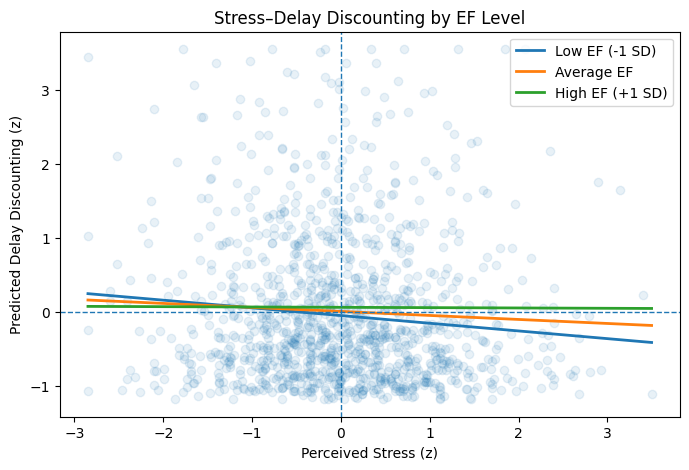

In [16]:
stress_grid = np.linspace(
    analytic_df["perceived_stress_z"].min(),
    analytic_df["perceived_stress_z"].max(),
    100
)

plt.figure(figsize=(8, 5))

plt.scatter(
    analytic_df["perceived_stress_z"],
    analytic_df["delay_discounting_z"],
    alpha=0.10
)

for ef, level in zip(
    [-1, 0, 1],
    ["Low EF (-1 SD)", "Average EF", "High EF (+1 SD)"]
):
    plot_df = pd.DataFrame({
        "perceived_stress_z": stress_grid,
        "ef_composite_z": ef
    })
    
    predictions = linear_model.predict(plot_df)

    plt.plot(
        stress_grid,
        predictions,
        linewidth=2,
        label=level
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)

plt.xlabel("Perceived Stress (z)")
plt.ylabel("Predicted Delay Discounting (z)")
plt.title("Stress–Delay Discounting by EF Level")
plt.legend()

plt.show()

### 3.5 Model Check

These plots provide a basic visual check of model assumptions.

- **Residuals vs fitted**: checks for systematic patterns or changes in spread  
- **Q-Q plot**: checks whether residuals are approximately normally distributed  

The residuals do not show strong patterns, though some deviation is visible at more extreme values. With HC3 robust standard errors, modest departures from constant variance are less concerning for inference.

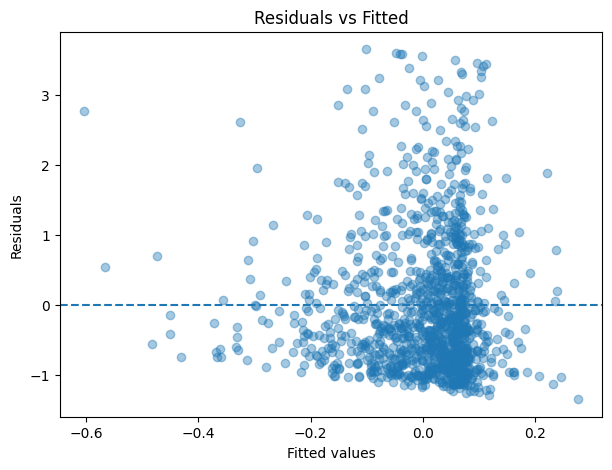

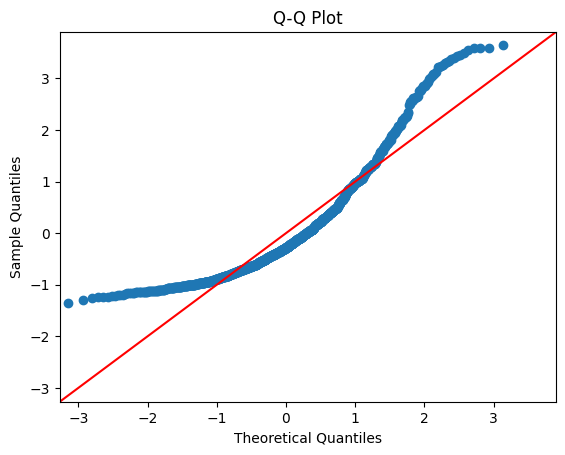

In [17]:
residuals = linear_model.resid
fitted = linear_model.fittedvalues

plt.figure(figsize=(7, 5))
plt.scatter(fitted, residuals, alpha=0.4)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

sm.qqplot(residuals, line="45")
plt.title("Q-Q Plot")
plt.show()

### 3.6 Interim Interpretation

The inferential results provide limited support for the moderation hypothesis. The interaction between perceived stress and executive function is weak, and overall model fit is low, suggesting these variables explain little variation in delay discounting.

Given these weak effects, the next step is to evaluate whether a broader set of variables improves predictive performance out of sample.

### 4. Predictive Models: Do These Variables Generalize Out of Sample?

The inferential models test relationships within the sample. This section evaluates whether these variables can predict delay discounting in unseen individuals.

Three models are compared:

- **OLS**: standard linear regression  
- **Ridge**: shrinks coefficients to reduce overfitting  
- **Elastic Net**: combines shrinkage and variable selection  

Performance is evaluated using out-of-sample **R²** on a held-out test set.

### Additional Variables for Predictive Modeling

To capture a broader behavioral profile, additional cognitive, personality, and affective variables are included:

- **Cognitive**: fluid intelligence (PMAT24_A_CR), processing speed (ProcSpeed_AgeAdj)  
- **Personality**: conscientiousness, neuroticism, extraversion (NEO-FFI)  
- **Affective**: fear, anger/hostility, sadness, positive affect  

These variables extend the model beyond the main hypothesis and allow evaluation of broader behavioral signal.

In [18]:
# Define predictors for predictive modeling
predictor_columns = [
    "perceived_stress_z",
    "ef_composite_z",
    "perceived_stress_z_sq",
    "PMAT24_A_CR",
    "ProcSpeed_AgeAdj",
    "NEOFAC_C",
    "NEOFAC_N",
    "NEOFAC_E",
    "FearAffect_Unadj",
    "AngHostil_Unadj",
    "Sadness_Unadj",
    "PosAffect_Unadj"
]

# Construct feature matrix (X) and outcome vector (y)
X = analytic_df[predictor_columns].copy()
y = analytic_df["delay_discounting_z"].copy()

### 4.1 Train/Test Split

The dataset is split into training and test sets, with 20% reserved as held-out data.

Models are fit on the training set and evaluated on the test set, which is not used during fitting. This provides a cleaner estimate of how well the models generalize to unseen individuals.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

### 4.2 Feature Scaling

Predictors are standardized by fitting a scaler on the training data and applying it to both training and test sets.

This places variables on a common scale and avoids **data leakage**, meaning the test set does not influence how the predictors are transformed.

In [20]:
feature_scaler = StandardScaler()

X_train_scaled = feature_scaler.fit_transform(X_train)
X_test_scaled = feature_scaler.transform(X_test)

### 4.3 Fit Predictive Models

The predictive models are fit on the scaled training data.

For Ridge and Elastic Net, cross-validation is used to select regularization settings that balance model flexibility and overfitting.

In [21]:
regularization_grid = np.logspace(-3, 3, 100)

# Ordinary Least Squares
ols_predictive_model = LinearRegression()
ols_predictive_model.fit(X_train_scaled, y_train)

# Ridge with cross-validation
ridge_predictive_model = RidgeCV(alphas=regularization_grid, cv=5)
ridge_predictive_model.fit(X_train_scaled, y_train)

# Elastic Net with cross-validation
elastic_net_model = ElasticNetCV(
    alphas=regularization_grid,
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
    cv=5,
    random_state=RANDOM_STATE,
    max_iter=10000
)
elastic_net_model.fit(X_train_scaled, y_train)

,"l1_ratio l1_ratio: float or list of float, default=0.5Float between 0 and 1 passed to ElasticNet (scaling betweenl1 and l2 penalties). For ``l1_ratio = 0``the penalty is an L2 penalty. For ``l1_ratio = 1`` it is an L1 penalty.For ``0 < l1_ratio < 1``, the penalty is a combination of L1 and L2This parameter can be a list, in which case the differentvalues are tested by cross-validation and the one giving the bestprediction score is used. Note that a good choice of list ofvalues for l1_ratio is often to put more values close to 1(i.e. Lasso) and less close to 0 (i.e. Ridge), as in ``[.1, .5, .7,.9, .95, .99, 1]``.","[0.1, 0.3, ...]"
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path, used for each l1_ratio... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path, used for each l1_ratio.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",array([1.0000...00000000e+03])
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"verbose verbose: bool or int, default=0Amount of verbosity.",0


### 4.4 Evaluate Out-of-Sample Performance

In addition to test R², I also report RMSE:

- **R²** reflects how much variance in the outcome is explained relative to a baseline model  
- **RMSE** reflects the typical magnitude of prediction error in outcome units

In [22]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return {
        "r_squared": r2_score(y_true, y_pred),
        "rmse": rmse
    }

ols_test_predictions = ols_predictive_model.predict(X_test_scaled)
ridge_test_predictions = ridge_predictive_model.predict(X_test_scaled)
elastic_test_predictions = elastic_net_model.predict(X_test_scaled)

ols_metrics = regression_metrics(y_test, ols_test_predictions)
ridge_metrics = regression_metrics(y_test, ridge_test_predictions)
elastic_metrics = regression_metrics(y_test, elastic_test_predictions)

predictive_performance = pd.DataFrame([
    {
        "model": "OLS",
        "test_r2": ols_metrics["r_squared"],
        "test_rmse": ols_metrics["rmse"],
        "best_alpha": np.nan,
        "best_l1_ratio": np.nan
    },
    {
        "model": "Ridge",
        "test_r2": ridge_metrics["r_squared"],
        "test_rmse": ridge_metrics["rmse"],
        "best_alpha": ridge_predictive_model.alpha_,
        "best_l1_ratio": np.nan
    },
    {
        "model": "Elastic Net",
        "test_r2": elastic_metrics["r_squared"],
        "test_rmse": elastic_metrics["rmse"],
        "best_alpha": elastic_net_model.alpha_,
        "best_l1_ratio": elastic_net_model.l1_ratio_
    }
])

predictive_performance

,model,test_r2,test_rmse,best_alpha,best_l1_ratio
0,OLS,-0.0128,0.9458,NaN,NaN
1,Ridge,0.0012,0.9392,187.3817,NaN
2,Elastic Net,-0.0003,0.9399,0.0248,0.7000


### 4.5 Ridge Coefficient Inspection

Ridge regression shrinks coefficients but does not set them to zero.

The coefficients are shown to examine the relative distribution of signal across predictors after shrinkage.

In [23]:
ridge_coefficient_table = (
    pd.DataFrame({
        "predictor": predictor_columns,
        "ridge_coefficient": ridge_predictive_model.coef_
    })
    .assign(abs_coefficient=lambda df: df["ridge_coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
    .drop(columns="abs_coefficient")
)

ridge_coefficient_table

,predictor,ridge_coefficient
3,PMAT24_A_CR,0.1536
10,Sadness_Unadj,0.0835
9,AngHostil_Unadj,-0.0626
6,NEOFAC_N,-0.0578
5,NEOFAC_C,-0.0469
11,PosAffect_Unadj,0.0312
0,perceived_stress_z,-0.0291
7,NEOFAC_E,0.0225
8,FearAffect_Unadj,0.0202
1,ef_composite_z,0.0141


### 4.6 Interpreting the Predictive Results

The predictive models address whether these variables meaningfully forecast outcomes in unseen individuals.

Despite interpretable coefficients, all models show near-zero out-of-sample R², indicating very weak predictive signal.

The slight improvement of Ridge over OLS suggests some overfitting in the unregularized model, while the lack of improvement from Elastic Net suggests the signal is not strongly sparse.

### 5. Results Summary

The main findings are summarized below across both inferential and predictive analyses.

- The linear moderation model explained very little variance in delay discounting.  
- Adding a nonlinear stress term did not meaningfully improve fit.  
- Out-of-sample predictive performance was weak across OLS, Ridge, and Elastic Net.  

Overall, the results provide limited support for the idea that executive function meaningfully buffers the relationship between stress and delay discounting in this dataset.

In [24]:
final_summary_table = pd.DataFrame({
    "analysis_stage": [
        "Inferential: Linear moderation",
        "Inferential: Nonlinear moderation",
        "Predictive: OLS",
        "Predictive: Ridge",
        "Predictive: Elastic Net"
    ],
    "primary_metric_name": [
        "R²", "R²", "Test R²", "Test R²", "Test R²"
    ],
    "primary_metric_value": [
        linear_model.rsquared,
        nonlinear_model.rsquared,
        predictive_performance.loc[predictive_performance["model"] == "OLS", "test_r2"].values[0],
        predictive_performance.loc[predictive_performance["model"] == "Ridge", "test_r2"].values[0],
        predictive_performance.loc[predictive_performance["model"] == "Elastic Net", "test_r2"].values[0],
    ]
}).round(3)

final_summary_table

,analysis_stage,primary_metric_name,primary_metric_value
0,Inferential: Linear moderation,R²,0.0100
1,Inferential: Nonlinear moderation,R²,0.0100
2,Predictive: OLS,Test R²,-0.0130
3,Predictive: Ridge,Test R²,0.0010
4,Predictive: Elastic Net,Test R²,-0.0000


### 6. Discussion

This project tested whether executive function buffers the relationship between perceived stress and delay discounting in a large adult behavioral sample.

The overall pattern was consistent across analyses: the observed effects were small, the interaction term was not meaningful, and predictive performance remained weak out of sample. Together, these findings suggest that the variables included here explain only a limited portion of individual differences in delay discounting.

Several limitations are worth noting. The analysis is cross-sectional, so the results should not be interpreted causally. Executive function is also a broad construct and is only imperfectly represented by the three-task composite used here. In addition, complete-case analysis is easy to interpret but may remove information if missingness is systematic.

More broadly, these findings suggest that delay discounting may depend on a wider range of influences than the trait-level cognitive, personality, and affective measures included in this notebook.

### 7. Portfolio Takeaway

This notebook demonstrates a full behavioral modeling workflow: data preparation, composite construction, moderation analysis, robust inference, and out-of-sample predictive evaluation.

It also shows the ability to communicate weak or null-leaning results clearly rather than overstating the evidence.

Future work could explore longitudinal data or richer behavioral measures to better capture variability in decision-making.

### Appendix: Saving Processed Dataset

Saving the processed dataset makes the workflow more reproducible and easier to reuse without repeating the full data preparation process.

In [25]:
analytic_df.to_csv("../data/hcp_modeling_dataset.csv", index=False)
print("Saved processed dataset to ../data/hcp_modeling_dataset.csv")

Saved processed dataset to ../data/hcp_modeling_dataset.csv
